# Representación vectorial del lenguaje en un corpus político

**Presentado por:** Natali Angarita Escolar 

**Maestría en Estadística Aplicada**
Universidad del Norte

---

## 1. Introducción

El lenguaje natural requiere de la construcción de una cadena de procesamiento que permita transformar sus  símbolos, palabras y estructuras, en objetos numéricos que puedan ser interpretados por las computadoras. De manera simplifica, implica traducir nuestro lenguaje a vectores numéricos. 

En este sentido, es fundamental un paso previo a la construicción de dichos vectores, pues, tal como vimos en el documento anterior sobre técnicas de tokenización, las decisiones que se tomen al momento de hacer la limpieza del texto, la normalización y/o definir el lexicon, así como las que serán aboradas a lo largo de este segundo documento,definen la información que se conserva y aquella que puede perderse, y así mismo, la interpretabilidad y el rendimiento de los modelos de aprendizaje automático. 

En este segundo ejercicio práctico, se integran cuatro técnicas claves de representación de texto: la bolsa de palabras (*Bag of Words*, BoW), la ponderación TF-IDF (*Term Frequency-Inverse Document Frequency*), la similitud coseno y la codificación *one-hot*. Cada una de estas técnicas será construida, interpretada y comparada sobre un mismo corpus, el cuál fue construido intencionalmente, para propiciar el uso de las mismas. Resulta importante mencionar que éstas técnicas están basadas en frecuencias y conteo. No obstante no ahodan en el significado de cada token (lo semántico) siguen siendo útiles en la práctica y proporcionan una base matemática sólida para métodos más avanzados. Adicionalemente, se integran las funciones vistas en un documento anterior sobre estrategias de tokenización, y normalización de texto. 

El objetivo de este ejercicio es presentar cómo los algoritmos de aprendizaje automático no operan sobre cadenas de texto sino sobre vectores numéricos. Esta actividad se enfoca en la dimensión sintáctica del lenguaje (patrones de aparición de palabras). A manera de información, abordaremos en próximos ejercicios prácticas, cómo los modelos además de la estructura del texto, logran capturar su significado.

---

## 2. Descripción del corpus

El corpus es el conjunto de documentos o textos que sirve como materia prima para construir las representaciones numéricas del lenguaje. 

En este ejercicio está compuesto por tres oraciones en inglés, relacioandas con la política como disciplina de estudio. Fueron construidas de manera intencional con apoyo de ChatGPT para propiciar el uso de las herramientas que se abordarán a lo largo de este documento. 

Por ejemplo, observamos que la palabra "Public" está escrita con mayúscula en la segunda oración, y minúscula en la tercera; así como el uso de conectores o "palabras carentes de significado" entre otras. Cada oración se constituye como un documento independiente:

| ID | Documento |
|----|-----------|
| D1 | *Political institutions shape public policy and influence democratic governance.* |
| D2 | *Public policy decisions affect economic development and social outcomes.* |
| D3 | *Democratic governance relies on institutions, political participation, and public trust.* |

Los tres documentos resultan apropiados para ejercicios propuesto toda vez que, 
1. Comparten términos comunes como "public", "policy", "institutions" y "governance", pero cada una las combina de forma diferente. Esto permite demostrar que métodos como TF-IDF puedan mostrar cómo pondera frecuencia de token vs. número de documentos en aparece.
2. La matriz de vectores será manejable en tanto son oraciones cortas. 
3. La temática es coherente los tres documentos, aunque son significados distintos. Todas hablan de fenómenos propios de la política. Es decir, comparten un campo semántico común (instituciones, política pública, gobernanza democrática) pero difieren en su énfasis temático.
4. Permiten evidenciar las limitaciones de las técnicas que serán abordadas. 



---

## 3. Configuración del entorno y dependencias

La siguiente celda instala los recursos de NLTK necesarios y carga todas las librerías utilizadas en el cuaderno. Debe ejecutarse una sola vez.

In [32]:
# ── Instalación de recursos NLTK ──────────────────────────
import nltk
for resource in ['stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass  # en entornos sin acceso a internet se usa la lista manual más abajo

# ── Librerías estándar ────────────────────────────────────────────────────────
import re
import numpy as np
import pandas as pd

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

# ── NLTK ─────────────────────────────────────────────────────────────────────
try:
    from nltk.corpus import stopwords as nltk_sw
    from nltk.stem.wordnet import WordNetLemmatizer
    STOP_EN = set(nltk_sw.words('english'))
    LEMMATIZER = WordNetLemmatizer()
    USE_NLTK = True
except Exception:
    # Fallback: lista manual de stopwords en inglés
    STOP_EN = {
        'a','an','the','and','or','but','in','on','at','to','for','of','with',
        'is','are','was','were','be','been','being','have','has','had','do',
        'does','did','will','would','shall','should','may','might','can','could',
        'must','that','this','these','those','it','its','i','you','he','she',
        'we','they','me','him','her','us','them','my','your','his','our','their',
        'what','which','who','how','when','where','why','if','not','no','nor',
        'so','yet','both','either','neither','each','few','more','most','other',
        'some','such','than','then','there','here','also','just','as','up','out',
        'about','into','through','before','after','above','below','between',
        'own','same','from','by','off','over','under','again','while','because'
    }
    LEMMATIZER = None
    USE_NLTK = False

print(f'NLTK disponible: {USE_NLTK}')
print(f'Stopwords cargadas: {len(STOP_EN)} términos')

pd.set_option('display.max_columns', None)

# ── Corpus ───────────────────────────────────────────────────────────────────
documents = [
    "Political institutions shape public policy and influence democratic governance.",
    "Public policy decisions affect economic development and social outcomes.",
    "Democratic governance relies on institutions, political participation, and public trust."
]
corpus = pd.Series(documents, name='documento')
print('\nCorpus cargado:')
for i, doc in enumerate(documents, 1):
    print(f'  D{i}: {doc}')

NLTK disponible: True
Stopwords cargadas: 198 términos

Corpus cargado:
  D1: Political institutions shape public policy and influence democratic governance.
  D2: Public policy decisions affect economic development and social outcomes.
  D3: Democratic governance relies on institutions, political participation, and public trust.


---

## 3. Preprocesamiento

Antes de vectorizar, el texto debe estandarizarse. El preprocesamiento opera en cuatro pasos consecutivos:

1. **Lowercasing:** se convierte todo el texto a minúsculas para que *Policy* y *policy* sean el mismo token. Este paso es necesario porque los algoritmos tratan las cadenas de texto de forma literal: sin esta normalización, Democratic y democratic serían consideradas dos palabras distintas, inflando artificialmente el vocabulario y fragmentando la información de frecuencia.
2. **Eliminación de puntuación:** se remueven todos los caracteres que no son letras (comas, puntos, etc.) usando una expresión regular. Sin este paso, governance. y governance serían tratados como tokens diferentes, cuando en realidad representan la misma unidad léxica.
3. **Eliminación de *stopwords*:** se descartan palabras funcionales de alta frecuencia (*and*, *on*, *the*) que no aportan significado distrintivo entre documentos.En este ejemplo, serían en el D1 (and), en el D2 (and) y en el D3 (on, and).
4. **Lematización:** cada token se reduce a su forma canónica (*institutions* = *institution*; *decisions* = *decision*). La lematización utiliza conocimiento morfológico y gramatical para obtener la raíz correcta de cada palabra. Esto permite que variantes flexivas de una misma palabra (govern, governs, governed, governing) sean tratadas como un único token, reduciendo la dispersión del vocabulario sin perder significado.

El resultado es un corpus normalizado donde cada documento queda representado por sus tokens léxicamente significativos.

In [31]:
# ── Función de preprocesamiento ───────────────────────────────────────────────
def simple_stem(word):
    for suffix in ('ances', 'ences', 'ments', 'tions', 'ings', 'ness',
                   'tion', 'ance', 'ence', 'ing', 'ment', 'ies', 'es', 's'):
        if word.endswith(suffix) and len(word) - len(suffix) > 3:
            return word[:-len(suffix)]
    return word

def preprocess(text):
    # Paso 1 y 2: lowercase + eliminar caracteres no alfabéticos
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    tokens = text.split()

    # Paso 3: eliminar stopwords
    tokens = [t for t in tokens if t not in STOP_EN]

    # Paso 4: lematización
    if USE_NLTK and LEMMATIZER is not None:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    else:
        tokens = [simple_stem(t) for t in tokens]

    return tokens

# ── Aplicación al corpus ──────────────────────────────────────────────────────
print('-' * 65)
print('PREPROCESAMIENTO DEL CORPUS')
print('-' * 65)

processed_tokens = []
processed_strings = []

for i, doc in enumerate(documents, 1):
    raw   = doc
    lower = re.sub(r'[^a-zA-Z]', ' ', doc).lower()
    no_sw = [t for t in lower.split() if t not in STOP_EN]
    if USE_NLTK and LEMMATIZER is not None:
        lemma = [LEMMATIZER.lemmatize(t) for t in no_sw]
    else:
        lemma = [simple_stem(t) for t in no_sw]

    processed_tokens.append(lemma)
    processed_strings.append(' '.join(lemma))

    print(f'\nDocumento D{i}:')
    print(f'  Original   : {raw}')
    print(f'  Lowercase  : {lower.strip()}')
    print(f'  Sin SW     : {", ".join(no_sw)}')
    print(f'  Lematizado : {", ".join(lemma)}')

print()

# Tabla resumen
df_prep = pd.DataFrame({
    'Documento': [f'D{i}' for i in range(1, 4)],
    'Tokens preprocesados': processed_strings
})
print(df_prep.to_string(index=False))

-----------------------------------------------------------------
PREPROCESAMIENTO DEL CORPUS
-----------------------------------------------------------------

Documento D1:
  Original   : Political institutions shape public policy and influence democratic governance.
  Lowercase  : political institutions shape public policy and influence democratic governance
  Sin SW     : political, institutions, shape, public, policy, influence, democratic, governance
  Lematizado : political, institution, shape, public, policy, influence, democratic, governance

Documento D2:
  Original   : Public policy decisions affect economic development and social outcomes.
  Lowercase  : public policy decisions affect economic development and social outcomes
  Sin SW     : public, policy, decisions, affect, economic, development, social, outcomes
  Lematizado : public, policy, decision, affect, economic, development, social, outcome

Documento D3:
  Original   : Democratic governance relies on institutions,


### 3.1 Resultado del Preprocesamiento del Corpus
El pipeline de preprocesamiento fue aplicado de forma exitosa a los tres documentos del corpus. A continuación se describe lo que ocurrió en cada etapa y qué se puede observar en los resultados.

1. **Lowercase** no produjo cambios dramáticos visibles, pero garantizó consistencia: palabras como Political (D1), Public (D2) y Democratic (D3), que comenzaban con mayúscula por estar al inicio de la oración, fueron normalizadas junto con el resto del texto.

2. **Stopwords** tuvo un cambio notorio. La elminación de palabras como *and*, *on* fueron descartadas en todos los documentos, reduciendo el tamaño de cada oración sin perder contenido informativo. Por ejemplo, D3 pasó de 13 palabras a 8 tokens significativos.

3. **Lematización** igualmente produjo cambios precisos y puntuales. Los casos más evidentes son institutions = institution (D1 y D3), decisions = decision y outcomes = outcome (D2). Específicamente, en D3 el token *relies* no fue lematizado correctamente a rely, lo cual es un comportamiento que puede ocurrir dependiendo del lematizador utilizado y evidencia una limitación menor de la ténica.

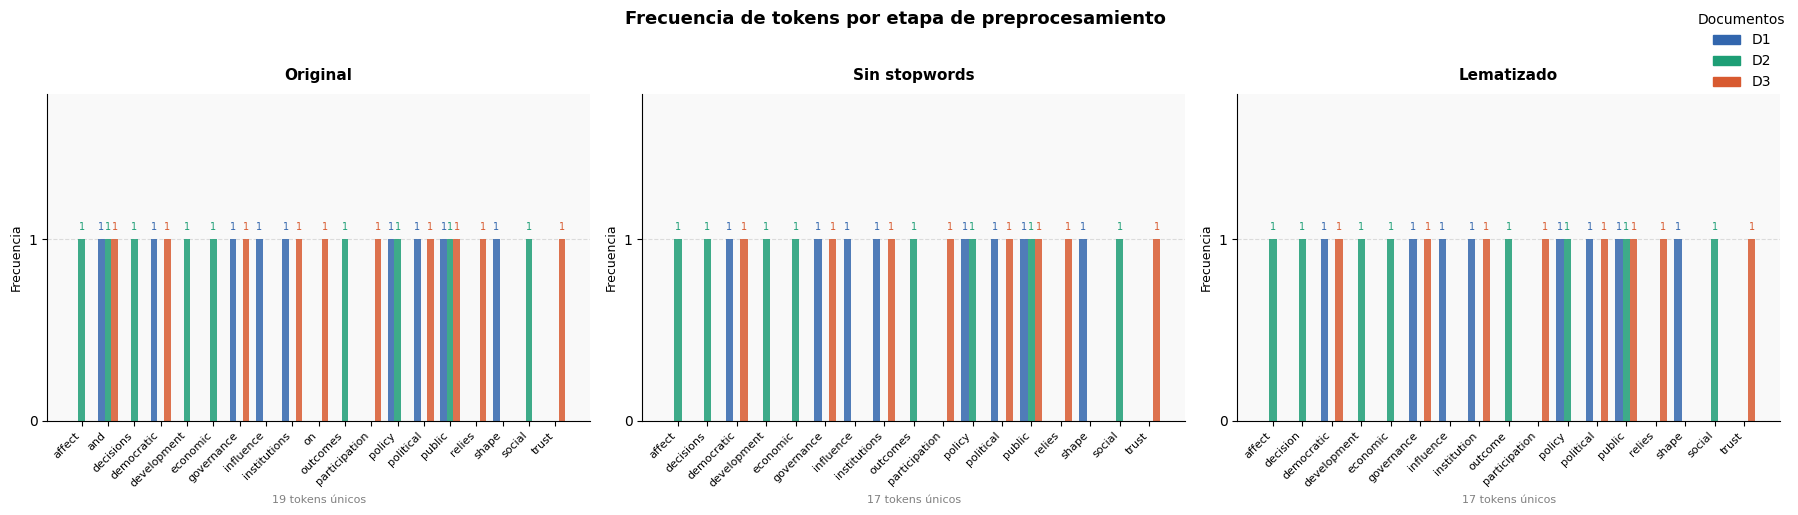

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Frecuencia de tokens por etapa de preprocesamiento",
             fontsize=13, fontweight="bold", y=1.02)

colores = {"D1": "#3266ad", "D2": "#1D9E75", "D3": "#D85A30"}

etapas = {
    "Original": [
        re.sub(r'[^a-zA-Z]', ' ', doc).lower().split()
        for doc in documents
    ],
    "Sin stopwords": [
        [t for t in re.sub(r'[^a-zA-Z]', ' ', doc).lower().split() if t not in STOP_EN]
        for doc in documents
    ],
    "Lematizado": processed_tokens
}

for ax, (etapa, token_lists) in zip(axes, etapas.items()):

    all_tokens = sorted(set(tok for tl in token_lists for tok in tl))
    x          = np.arange(len(all_tokens))
    width      = 0.25

    for j, (tokens, doc_id) in enumerate(zip(token_lists, ["D1","D2","D3"])):
        counts = [tokens.count(tok) for tok in all_tokens]
        ax.bar(x + j*width, counts, width, color=colores[doc_id],
               alpha=0.85, zorder=2)

        for xi, c in zip(x + j*width, counts):
            if c > 0:
                ax.text(xi, c + 0.05, str(c), ha='center',
                        fontsize=7, color=colores[doc_id])

    ax.set_title(etapa, fontsize=11, fontweight="bold", pad=10)
    ax.set_xticks(x + width)
    ax.set_xticklabels(all_tokens, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.8)
    ax.set_yticks([0, 1])
    ax.set_ylabel("Frecuencia", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax.set_facecolor("#f9f9f9")
    ax.set_xlabel(f"{len(all_tokens)} tokens únicos", fontsize=8, color="gray")

patches = [mpatches.Patch(color=colores[d], label=d) for d in ["D1","D2","D3"]]
fig.legend(handles=patches, loc="upper right", fontsize=10,
           frameon=False, title="Documentos")

plt.tight_layout()
plt.savefig("preprocesamiento_frecuencias.png", dpi=150, bbox_inches="tight")
plt.show()

Los gráficos anteriroes muestran la frecuencia de los tokens en cada etapa del preprocesamiento del texto. Se observa que, aunque el número de términos únicos se reduce después de eliminar stopwords y aplicar lematización, la frecuencia de aparición de los tokens relevantes se mantiene estable. Esto indica que el preprocesamiento logra simplificar el corpus al eliminar ruido, sin perder información importante para el análisis.

---

## 4. Representación Bag of Words (BoW)

Para entender este modelo, basta con imaginar un documento en una sola bolsa de palabras, en donde no importa el orden, la gramática, o el contexto. Lo único que resulta relevante es qué palabras aparecen y cuántas veces aparecen.
De manera anticipada podemos preveer sus limitaciones. No tiene el mismo significado decir  *El gato persiguió al raton* que decir *El ratón persiguió al gato* aunque tiene las mismas palabras.

La representación *Bag of Words* traduce cada documento en un vector de enteros donde cada posición corresponde a un término del vocabulario y el valor almacenado es la frecuencia con que ese término aparece en el documento.Es decir, primero se recorre todo el corpus y se construye una lista de todos los tokens únicos encontrados. Este vocabulario define las dimensiones del espacio vectorial. Si el vocabulario tiene 10 términos únicos, se tendrá un espacio de 10 dimensiones.En segundo lugar, se realiza un conteo por documento. Para cada documento, se recorre su lista de tokens y se cuenta cuántas veces aparece cada término del vocabulario. El resultado es un vector donde cada posición corresponde a un término específico y el valor almacenado es su frecuencia en ese documento. Si un término del vocabulario no aparece en el documento, su posición simplemente toma el valor de cero. El resultado final es una matriz de términos por documentos (o document-term matrix), donde las filas son los documentos y las columnas son los términos del vocabulario.

Para construir esta representación se utiliza `CountVectorizer` de *scikit-learn*, que automatiza la tokenización, la construcción del vocabulario y el conteo de frecuencias. Se alimenta el corpus ya preprocesado para que la matriz resultante refleje los tokens normalizados.

In [46]:
# ── Bag of Words con CountVectorizer ─────────────────────────────────────────
cv = CountVectorizer()
bow_matrix = cv.fit_transform(processed_strings)


vocab = cv.get_feature_names_out()
bow_array = bow_matrix.toarray()

print('-' * 65)
print('REPRESENTACIÓN BAG OF WORDS')
print('-' * 65)

# Vocabulario
print(f'\nVocabulario aprendido ({len(vocab)} términos):')
print(', '.join(vocab))

# Matriz documento-término
df_bow = pd.DataFrame(
    bow_array,
    index=[f'D{i}' for i in range(1, 4)],
    columns=vocab
)

from IPython.display import HTML, display

print('\nMatriz documento-término (BoW):')

display(HTML(f"""
<div style="overflow-x: auto;">
    {df_bow.to_html()}
</div>

<style>
table {{
    font-size: 9px;
    border-collapse: collapse;
}}
td, th {{
    white-space: nowrap;
    padding: 4px;
}}
</style>
"""))

# Estadísticas de dispersión
print('-' * 65)
print('ESTADÍSTICAS DE DISPERSIÓN')
print('-' * 65)
total_entries = bow_array.size
nonzero       = np.count_nonzero(bow_array)
sparsity      = 1 - nonzero / total_entries

print(f'\nDimensionalidad : {bow_array.shape[0]} documentos × {bow_array.shape[1]} términos')
print(f'Entradas totales: {total_entries}')
print(f'Entradas nonzero: {nonzero}')
print(f'Dispersión      : {sparsity:.1%}')

-----------------------------------------------------------------
REPRESENTACIÓN BAG OF WORDS
-----------------------------------------------------------------

Vocabulario aprendido (17 términos):
affect, decision, democratic, development, economic, governance, influence, institution, outcome, participation, policy, political, public, relies, shape, social, trust

Matriz documento-término (BoW):


,affect,decision,democratic,development,economic,governance,influence,institution,outcome,participation,policy,political,public,relies,shape,social,trust
D1,0,0,1,0,0,1,1,1,0,0,1,1,1,0,1,0,0
D2,1,1,0,1,1,0,0,0,1,0,1,0,1,0,0,1,0
D3,0,0,1,0,0,1,0,1,0,1,0,1,1,1,0,0,1


-----------------------------------------------------------------
ESTADÍSTICAS DE DISPERSIÓN
-----------------------------------------------------------------

Dimensionalidad : 3 documentos × 17 términos
Entradas totales: 51
Entradas nonzero: 24
Dispersión      : 52.9%


In [10]:
vocab

array(['affect', 'decision', 'democratic', 'development', 'economic',
       'governance', 'influence', 'institution', 'outcome',
       'participation', 'policy', 'political', 'public', 'relies',
       'shape', 'social', 'trust'], dtype=object)

In [11]:
len(vocab)

17

El vocabulario construido tiene en total 17 términos únicos. La matriz tiene dimensiones 3 × 17, donde 3 es el número de documentos, y 17 son los token únicos. Cada fila es el vector BoW de un documento y cada columna corresponde a un término único del corpus preprocesado. En total la matriz tiene 51 entradas, de las cuales 27 son 0 y 21 son 1. Ningún documento contiene todos los términos del vocubulario conjunto. 

Por último tenemos que la dispersión es del 52.9. Esto indica que tan "vacia" está la matriz. Observamos lo que ya habiamos anticipado anteriomente, pues el número de 0, es superior al de 1. 

Los términos que aparecen en más de un documento —como *public*, *policy*, *institution*, *governance*, *democratic* y *political*— son los que potencialmente vinculan los tres documentos entre sí y los que la similitud coseno detectará como señales de proximidad.

A continuación se realiza una representaición gráfica de la frecuencia de cada token.

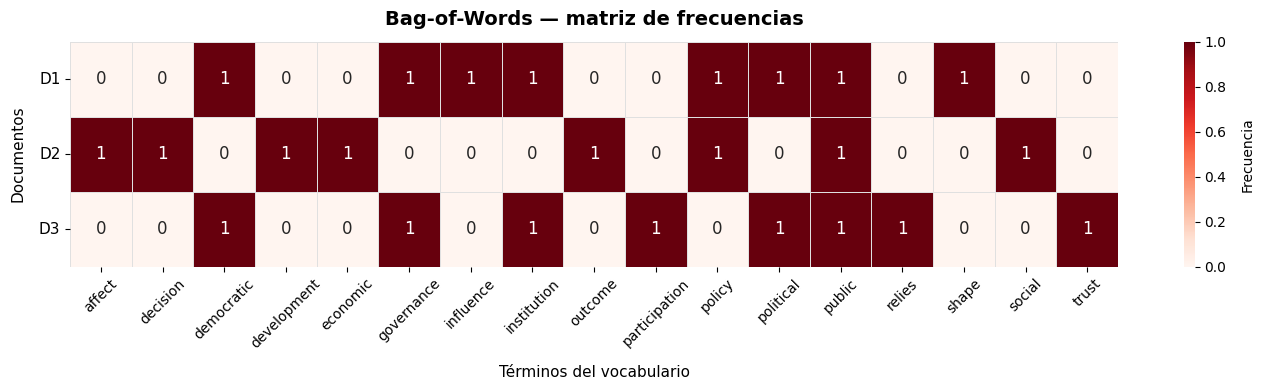

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

vocab  = cv.get_feature_names_out()
X      = bow_matrix.toarray()
df_bow = pd.DataFrame(X, columns=vocab,
                      index=[f"D{i+1}" for i in range(len(documents))])

fig, ax = plt.subplots(figsize=(14, 4))

sns.heatmap(
    df_bow,
    cmap="Reds",
    cbar=True,
    linewidths=0.5,
    linecolor="#e0e0e0",
    annot=True,
    fmt="d",
    annot_kws={"size": 12},
    ax=ax
)

ax.set_title("Bag-of-Words — matriz de frecuencias", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Términos del vocabulario", fontsize=11, labelpad=10)
ax.set_ylabel("Documentos", fontsize=11, labelpad=10)

ax.tick_params(axis="x", labelsize=10, rotation=45)
ax.tick_params(axis="y", labelsize=11, rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Frecuencia", fontsize=10, labelpad=10)

plt.tight_layout()
plt.savefig("bow_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


La función `CountVectorizer` permite jugar con la separación por unigramas, bigramas o trigramas. Esto permite evidenciar como crece el vocabulario al incluir combinaciones de palabras. Tenemos que, 

1. Los unigramas son exactamente los 17 términos únicos que fueron identificados en el vocabulario BoW original.
2. Los bigramas empiezan a capturar relaciones entre palabras adyacentes que BoW por si misma ignora. Por ejemplo, "public policy" y "policy decision" son conceptos distintos aunque compartan la palabra policy.
3. Los trigramas capturan secuencias de contexto más elaboradas. Tenemos por ejemplo, "public policy decision" vs "public policy influence", ambos empiezan igual pero terminan diferente, lo que refleja que D2 habla de decisiones y D1 de influencia. Esto es exactamente lo que BoW simple no puede ver.

In [20]:
tok_tbl = pd.DataFrame({
    "Token ID": range(1, len(terms_ngram) + 1),
    "Token": terms_ngram,
    "Unigram": ["✓" if len(t.split()) == 1 else "" for t in terms_ngram],
    "Bigram": ["✓" if len(t.split()) == 2 else "" for t in terms_ngram],
    "Trigram": ["✓" if len(t.split()) == 3 else "" for t in terms_ngram],
})

styled = (
    tok_tbl.style
    .set_caption("Vocabulario de n-gramas y clasificación de tokens por número de palabras.")
    .set_properties(subset=["Unigram", "Bigram", "Trigram"],
                    **{"text-align": "center"})
    .set_properties(subset=["Token ID"],
                    **{"text-align": "center"})
    .set_properties(subset=["Token"],
                    **{"text-align": "left", "font-style": "italic"})
    .map(lambda v: "color: #1D9E75; font-weight: bold;" if v == "✓" else "",
         subset=["Unigram", "Bigram", "Trigram"])
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "13px"), ("font-weight", "bold"),
                   ("text-align", "left"), ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#f2f2f2"), ("font-size", "12px"),
                   ("text-align", "center"), ("padding", "6px 12px"),
                   ("border-bottom", "2px solid #ccc")]},
        {"selector": "td",
         "props": [("font-size", "12px"), ("padding", "4px 12px"),
                   ("border-bottom", "1px solid #eee")]},
        {"selector": "tr:hover td",
         "props": [("background-color", "#f9f9f9")]},
    ])
    .hide(axis="index")
)

styled

Token ID,Token,Unigram,Bigram,Trigram
1,affect,✓,,
2,affect economic,,✓,
3,affect economic development,,,✓
4,decision,✓,,
5,decision affect,,✓,
6,decision affect economic,,,✓
7,democratic,✓,,
8,democratic governance,,✓,
9,democratic governance relies,,,✓
10,development,✓,,



La tabla presenta el vocabulario generado a partir del modelo de n-gramas, donde cada token es indexado de acuerdo con su posición en el corpus procesado. Asimismo, se clasifica cada término según su longitud en número de palabras, diferenciando entre unigramas, bigramas y trigramas. Esta distinción permite identificar la complejidad estructural de las unidades léxicas capturadas por el modelo, evidenciando la incorporación tanto de términos individuales como de secuencias de palabras que pueden aportar mayor contexto semántico. En particular, los trigramas permiten capturar mejor como se relacionan las palabras entre sí, lo cuál no es tan evidente en representaciones basadas únicamente en unigramas.


## 5. Representación TF-IDF

La ponderación TF-IDF combina dos componentes: la *frecuencia del término* (TF, cuántas veces aparece un token en un documento) y la *frecuencia inversa de documento* (IDF, en cuántos documentos aparece dicho token en el corpus).

La fórmula es:

$$
\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \log\left(\frac{N}{\text{DF}(t)}\right)
$$

Un término obtiene un peso alto cuando es frecuente dentro de su documento, pero poco común en el resto del corpus, lo que lo hace más discriminativo.

### 5.1 Frecuencia de término (TF)

Mide la **importancia local** de un token: cuántas veces aparece el término $t$ en el documento $d$. La lógica es simple: si una palabra aparece muchas veces en un documento, probablemente es relevante para ese contexto.

La limitación de TF es que no distingue entre palabras importantes y palabras frecuentes en todo el corpus.

### 5.2 Frecuencia inversa de documento (IDF)

Mientras que TF captura la relevancia local, IDF mide la **relevancia global**, es decir, qué tan informativa es una palabra en el conjunto de documentos.

La fórmula es:

$$
\text{IDF}(t) = \log\left(\frac{N}{\text{DF}(t)}\right)
$$

donde $N$ es el número total de documentos y $\text{DF}(t)$ es el número de documentos que contienen el término $t$.

La lógica es inversa: los tokens que aparecen en muchos documentos reciben un peso bajo, ya que son menos discriminativos. El uso del logaritmo evita que los términos poco frecuentes dominen excesivamente la ponderación.

### 5.3 TF-IDF como producto de importancia local y global

Un término recibe un peso alto en TF-IDF **solo si cumple dos condiciones simultáneamente**: es frecuente en el documento (TF alto) y es raro en el corpus (IDF alto). Si una de estas condiciones no se cumple, su peso disminuye.

Esto hace que TF-IDF sea robusto frente a dos tipos de ruido:

- Palabras muy comunes que aportan poca información → **IDF las penaliza**  
- Palabras poco frecuentes en el documento → **TF las penaliza**


### 5.4 Normalización L1 y L2

La normalización de los vectores TF-IDF es un paso fundamental para garantizar comparaciones adecuadas entre documentos. Por ejemplo, documentos más largos tienden a acumular más tokens, lo que puede generar diferencias en magnitud que no reflejan necesariamente diferencias en contenido.

La normalización permite llevar todos los vectores a una escala común, asegurando comparaciones más justas.

Existen dos enfoques principales:

- **Norma L1**: divide cada valor por la suma de los valores absolutos  
- **Norma L2**: divide cada valor por la raíz cuadrada de la suma de los cuadrados (norma euclídea)

Por defecto, `TfidfVectorizer` aplica la normalización $L_2$, lo que garantiza que todos los vectores tengan longitud unitaria en el espacio euclídeo.

In [27]:
# ── TF-IDF con TfidfVectorizer ────────────────────────────────────────────────
tfidf_vect  = TfidfVectorizer(norm='l2')
tfidf_matrix = tfidf_vect.fit_transform(processed_strings)
tfidf_array  = tfidf_matrix.toarray()

vocab_tfidf = tfidf_vect.get_feature_names_out()

print('-' * 65)
print('REPRESENTACIÓN TF-IDF (L2)')
print('-' * 65)

df_tfidf = pd.DataFrame(
    np.round(tfidf_array, 4),
    index=[f'D{i}' for i in range(1, 4)],
    columns=vocab_tfidf
)
df_tfidf

-----------------------------------------------------------------
REPRESENTACIÓN TF-IDF (L2)
-----------------------------------------------------------------


,affect,decision,democratic,development,economic,governance,influence,institution,outcome,participation,policy,political,public,relies,shape,social,trust
D1,0.0000,0.0000,0.3322,0.0000,0.0000,0.3322,0.4368,0.3322,0.0000,0.0000,0.3322,0.3322,0.2580,0.0000,0.4368,0.0000,0.0000
D2,0.3799,0.3799,0.0000,0.3799,0.3799,0.0000,0.0000,0.0000,0.3799,0.0000,0.2890,0.0000,0.2244,0.0000,0.0000,0.3799,0.0000
D3,0.0000,0.0000,0.3196,0.0000,0.0000,0.3196,0.0000,0.3196,0.0000,0.4202,0.0000,0.3196,0.2482,0.4202,0.0000,0.0000,0.4202


Encontramos como en el primer documento, el término con mayo peso otorgado fueron "influence" y "shape", términos que tienen una única apareción en el corpus. En contraste, la palabra "Public" es la que menor peso obtiene. Aquí podemos evidenciar las limitaciones de esta estrategia, pues las primeras, no resultan relevantes en el contexto de la disciplina politológica, sin el apellido de lo público, o político. Mientras que, "Public" resulta muy relevante. 

En el documento 2, encontramos con menor peso nuevamente "Public", seguido de "Policy", y en el último documento, observamos que "Trust", "Relies" y "Participation" tiene puntaje altos. En sistesís, observamos como los términos compartidos por los tres documentos, como *public* reciben un IDF bajo porque su cociente $\frac{N}{\text{DF}(t)}$ es pequeño: aparecen en todo el corpus y por tanto se entiende que aportan poca información para distinguir un documento de otro. En cambio, términos exclusivos de un solo documento como *affect*, *trust* o *shape* reciben un IDF alto, porque son raros en el corpus y por tanto altamente discriminativos.


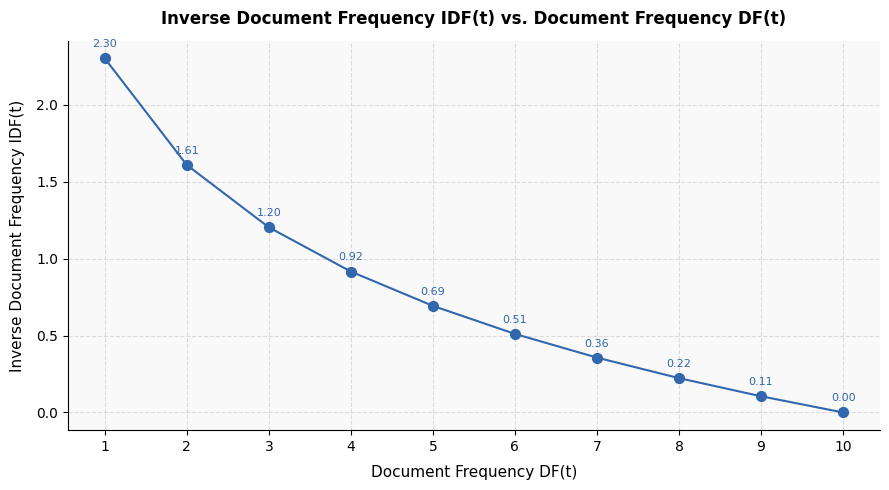

In [21]:
import numpy as np
import matplotlib.pyplot as plt

N = 10
df_t = np.arange(1, N + 1)
idf  = np.log(N / df_t)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_t, idf, color="#3266ad", linewidth=1.5, zorder=2)
ax.scatter(df_t, idf, color="#3266ad", s=50, zorder=3)

ax.set_title(
    "Inverse Document Frequency IDF(t) vs. Document Frequency DF(t)",
    fontsize=12, fontweight="bold", pad=12
)
ax.set_xlabel("Document Frequency DF(t)", fontsize=11, labelpad=8)
ax.set_ylabel("Inverse Document Frequency IDF(t)", fontsize=11, labelpad=8)

ax.set_xticks(range(1, N + 1))
ax.grid(axis="both", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("#f9f9f9")

for x, y in zip(df_t, idf):
    ax.annotate(
        f"{y:.2f}",
        xy=(x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="#3266ad"
    )

plt.tight_layout()
plt.savefig("idf_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### Diferencia entre BoW y TF-IDF

La diferencia entre BoW y TF-IDF puede evidenciarse en los valores numéricos de la matriz resultante.

En BoW, todos los términos que aparecen una vez en un documento reciben el mismo valor (1). Por ejemplo, una palabra como *public*, que aparece en los tres documentos del corpus, recibe exactamente el mismo peso que términos como *affect* o *trust*, que son exclusivos de un solo documento. En este enfoque, todos los términos tienen la misma importancia simplemente por su frecuencia dentro del documento.

En contraste, TF-IDF introduce una ponderación que considera tanto la frecuencia del término en el documento como su distribución en el corpus. Esto se refleja en el caso de *public*, cuyos pesos varían ligeramente entre documentos (D1: 0.2580, D2: 0.2244, D3: 0.2482). Es decir, aunque el término sigue presente, su relevancia se ajusta en función de su aparición en múltiples documentos.

Los términos exclusivos, como *influence* y *shape* en D1, o *participation*, *relies* y *trust* en D3, reciben los valores más altos dentro de sus respectivos documentos, ya que combinan alta frecuencia local con baja presencia global. Por el contrario, términos compartidos como *public*, *policy* o *democratic* reciben pesos más bajos, al aparecer en varios documentos.

En síntesis, mientras BoW trata todos los términos con igual frecuencia como igualmente relevantes, TF-IDF introduce una diferenciación que permite resaltar aquellos términos más informativos para cada documento, al considerar simultáneamente su uso local y su distribución en el corpus.

A continuación se presenta el cuadro comparativo.

In [29]:
# ── Comparación numérica BoW vs TF-IDF ───────────────────────────────────────
print('\n' + '-' * 70)
print('COMPARACIÓN BoW vs TF-IDF (por término, documento D1)')
print('-' * 70)

# Ambas matrices tienen el mismo vocabulario en este caso
compare_df = pd.DataFrame({
    'Término'  : vocab,
    'BoW  D1'  : bow_array[0],
    'BoW  D2'  : bow_array[1],
    'BoW  D3'  : bow_array[2],
    'TFIDF D1' : np.round(tfidf_array[0], 4),
    'TFIDF D2' : np.round(tfidf_array[1], 4),
    'TFIDF D3' : np.round(tfidf_array[2], 4),
})
print(compare_df.to_string(index=False))


----------------------------------------------------------------------
COMPARACIÓN BoW vs TF-IDF (por término, documento D1)
----------------------------------------------------------------------
      Término  BoW  D1  BoW  D2  BoW  D3  TFIDF D1  TFIDF D2  TFIDF D3
       affect        0        1        0    0.0000    0.3799    0.0000
     decision        0        1        0    0.0000    0.3799    0.0000
   democratic        1        0        1    0.3322    0.0000    0.3196
  development        0        1        0    0.0000    0.3799    0.0000
     economic        0        1        0    0.0000    0.3799    0.0000
   governance        1        0        1    0.3322    0.0000    0.3196
    influence        1        0        0    0.4368    0.0000    0.0000
  institution        1        0        1    0.3322    0.0000    0.3196
      outcome        0        1        0    0.0000    0.3799    0.0000
participation        0        0        1    0.0000    0.0000    0.4202
       policy        1

---

## 6. Análisis de similitud coseno

Luego de construidos los vectores, nos surge la pregunta de, ¿cómo podemos cuantificar que tan similares o no, son dos documentos? Para esto, la similitud coseno propone medir el ángulo entre dos vectores en el espacio vectorial. Su valor está comprendido entre 0 y 1 cuando los vectores son no negativos (como ocurre con BoW y TF-IDF): un valor de 1 indica que los documentos comparten exactamente la misma distribución de tokens (en la dirección del vector), mientras que un valor de 0 indica que no comparten ninguno.

$$\cos(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \, \|\mathbf{v}\|_2}$$

Ahora bien, dicha similitud también podría resultar negativa (−1) indicando direcciones opuestas. Sin embargo, en espacios TF-IDF esto es poco probable dado que todos los pesos son no negativos. A manera de ejemplo, podemos notar que, dos documentos con vocabularios completamente distintos producen similitud 0 (no negativa). Los valores intermedios, como 0.82 o 0.34, reflejan proximidad angular parcial: cuanto más se acerca el valor a 1, más alineados están los vectores y más similar es el contenido temático de los documentos.

Se calculan las similitudes por pares sobre las representaciones BoW y TF-IDF.

In [36]:
# ── Similitud coseno: función manual y verificación con sklearn ───────────────
def cosine_sim(u, v):
    u, v = np.array(u, dtype=float), np.array(v, dtype=float)
    denom = np.linalg.norm(u) * np.linalg.norm(v)
    return float(np.dot(u, v) / denom) if denom > 0 else 0.0

# ── Matriz de similitud coseno ────────────────────────────────────────────
n = len(documents)
doc_labels = [f'D{i}' for i in range(1, n+1)]

sim_bow = np.zeros((n, n))
sim_tfidf = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sim_bow[i, j]   = cosine_sim(bow_array[i], bow_array[j])
        sim_tfidf[i, j] = cosine_sim(tfidf_array[i], tfidf_array[j])

df_sim_bow   = pd.DataFrame(np.round(sim_bow,   4), index=doc_labels, columns=doc_labels)
df_sim_tfidf = pd.DataFrame(np.round(sim_tfidf, 4), index=doc_labels, columns=doc_labels)


In [34]:
print('-' * 55)
print('SIMILITUD COSENO — Bag of Words')
print('-' * 55)
print(df_sim_bow.to_string())

-------------------------------------------------------
SIMILITUD COSENO — Bag of Words
-------------------------------------------------------
       D1     D2     D3
D1  1.000  0.250  0.625
D2  0.250  1.000  0.125
D3  0.625  0.125  1.000


### 6.1 Similitud del Coseno — Bag of Words

La matriz de similitud de coseno sobre los vectores construidos con BoW revela que los documentos que presentan una mayor similitud son el D1 y el D3 (0.625). Esto coíncide con que comparten términos como mbos comparten términos como *democratic*, *governance*, *institution* y *political*.

D1 y D2 1 presentan una similitud moderada (0.250), comprensible en tanto sólo comparten los tokens *public* y *policy*. Por último, podemos mencionar que, D2 y D3 son los documentos más distantes del corpus (0.125), quienes sólo comparten un token.

In [35]:
print('\n' + '-' * 55)
print('SIMILITUD COSENO — TF-IDF')
print('-' * 55)
print(df_sim_tfidf.to_string())


-------------------------------------------------------
SIMILITUD COSENO — TF-IDF
-------------------------------------------------------
        D1      D2      D3
D1  1.0000  0.1539  0.4887
D2  0.1539  1.0000  0.0557
D3  0.4887  0.0557  1.0000


### 6.2 Similitud del Coseno — TF-IDF

La matriz de similitud coseno construida sobre los vectores TF-IDF muestra un patrón similar al observado con BoW, donde D1 y D3 presentan la mayor similitud, mientras que D2 y D3 son los más distantes. No obstante, los valores de similitud son más bajos en todos los pares, lo que refleja el efecto de la normalización y la ponderación de los términos, que reduce la influencia de aquellos menos discriminantes.

In [ ]:
# ── Identificar par más similar y menos similar (excluyendo diagonal) ─────────
print('\n' + '-' * 55)
print('RESUMEN DE PARES')
print('-' * 55)

for nombre, sim_mat in [('BoW', sim_bow), ('TF-IDF', sim_tfidf)]:
    sim_upper = sim_mat.copy()
    np.fill_diagonal(sim_upper, np.nan)

    max_idx = np.unravel_index(np.nanargmax(sim_upper), sim_upper.shape)
    min_idx = np.unravel_index(np.nanargmin(sim_upper), sim_upper.shape)

    max_val = sim_upper[max_idx]
    min_val = sim_upper[min_idx]

    print(f'\n[{nombre}]')
    print(f'  Par más similar  : D{max_idx[0]+1} – D{max_idx[1]+1}  (cos = {max_val:.4f})')
    print(f'  Par menos similar: D{min_idx[0]+1} – D{min_idx[1]+1}  (cos = {min_val:.4f})')


-------------------------------------------------------
RESUMEN DE PARES
-------------------------------------------------------

[BoW]
  Par más similar  : D1 – D3  (cos = 0.6250)
  Par menos similar: D2 – D3  (cos = 0.1250)

[TF-IDF]
  Par más similar  : D1 – D3  (cos = 0.4887)
  Par menos similar: D2 – D3  (cos = 0.0557)


### 6.3 Comparación entre las matrices de similitud de coseno BoW y TF-IDF

Comparar las dos matrices permite ver con claridad qué cambia cuando dejamos de contar palabras y empezamos a pesar su importancia.

En ambos métodos, el ordenamiento relativo de los pares se conserva: D1–D3 es siempre el par más similar y D2–D3 el más distante. Esto indica que la estructura temática del corpus es robusta y no depende del método de representación. Sin embargo, los valores absolutos son evidentemente distintos.

BoW + coseno reporta una similitud de 0.6250 entre D1 y D3, respondiendo a la pregunta *¿cuántas palabras comparten estos documentos?* La respuesta incluye términos como *public*, *political* e *institution*, que son comunes en el corpus y aportan al solapamiento sin ser especialmente informativos. TF-IDF + coseno reduce esa similitud a 0.4887, respondiendo a una pregunta más exigente: *¿comparten estos documentos palabras importantes y distintivas?* Al penalizar los términos genéricos, la similitud resultante es más conservadora y más honesta sobre el grado real de afinidad temática entre los documentos.

El efecto es aún más pronunciado en el par menos similar. D2–D3 pasa de 0.1250 en BoW a 0.0557 en TF-IDF. El 
débil puente que BoW percibía entre estos dos documentos estaba sostenido principalmente por *public*, el término con mayor frecuencia del corpus. TF-IDF lo discrimina y deja en evidencia que D2 y D3 describen realidades temáticas 
prácticamente independientes.

Esto confirma la distinción fundamental entre ambos enfoques: BoW captura solapamiento léxico y TF-IDF captura solapamiento informativo.

---

## 7. Representación *one-hot*

La codificación one-hot representa cada palabra del vocabulario como un vector de ceros y unos, donde solo una posición tiene valor 1 y todas las demás son 0. Esa posición indica el lugar que ocupa la palabra dentro del vocabulario. Por eso se llama one-hot, porque solo hay un “1 token caliente" en el vector.

En sintesís, cada token tiene su propio vector único que lo identifica, sin compartir información con otros.

A manera de ejemplo, se toman los tokens: 'democratic', 'institution', 'public'

In [44]:
# ── Vocabulario completo (ya construido por CountVectorizer) ──────────────────
vocab_list   = list(vocab)
vocab_size   = len(vocab_list)
token_to_idx = {tok: i for i, tok in enumerate(vocab_list)}

print('-' * 55)
print('CODIFICACIÓN ONE-HOT')
print('-' * 55)
print(f'\nVocabulario ({vocab_size} términos):')
print(', '.join(f'{i}:{t}' for i, t in enumerate(vocab_list)))

# ── Tres tokens seleccionados ─────────────────────────────────────────────────
selected_tokens = ['democratic', 'institution', 'public']

# Ajuste si la lematización produjo formas distintas
available = [t for t in selected_tokens if t in token_to_idx]
if len(available) < 3:
    available = vocab_list[:3]  # fallback: primeros 3 términos del vocabulario
selected_tokens = available[:3]

print(f'\nTokens seleccionados: {selected_tokens}')

one_hot_vectors = {}
for tok in selected_tokens:
    vec = np.zeros(vocab_size, dtype=int)
    vec[token_to_idx[tok]] = 1
    one_hot_vectors[tok] = vec

# Tabla 
df_onehot = pd.DataFrame(
    one_hot_vectors,
    index=vocab_list
).T
df_onehot.index.name = 'Token'
df_onehot.columns = list(range(len(vocab_list)))

print('\nVectores one-hot (filas = tokens, columnas = vocabulario):')
print(df_onehot.to_string())

# ── Similitud coseno entre vectores one-hot ────────────────────────────────────
print('\nSimilitud coseno entre vectores one-hot:')
for i, t1 in enumerate(selected_tokens):
    for j, t2 in enumerate(selected_tokens):
        if j > i:
            sim = cosine_sim(one_hot_vectors[t1], one_hot_vectors[t2])
            print(f'  cos({t1}, {t2}) = {sim:.4f}')

-------------------------------------------------------
CODIFICACIÓN ONE-HOT
-------------------------------------------------------

Vocabulario (17 términos):
0:affect, 1:decision, 2:democratic, 3:development, 4:economic, 5:governance, 6:influence, 7:institution, 8:outcome, 9:participation, 10:policy, 11:political, 12:public, 13:relies, 14:shape, 15:social, 16:trust

Tokens seleccionados: ['democratic', 'institution', 'public']

Vectores one-hot (filas = tokens, columnas = vocabulario):
             0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16
Token                                                                          
democratic    0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
institution   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0
public        0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0

Similitud coseno entre vectores one-hot:
  cos(democratic, institution) = 0.0000
  cos(democratic, public

Como enunciamos al inicio, en la representación one-hot, cada palabra se codifica como un vector binario de longitud igual al tamaño del vocabulario, en el que una única posición toma el valor de 1 y todas las demás son 0. Esto significa que cada término queda representado únicamente por su identidad y su posición en el vocabulario, sin incorporar información sobre frecuencia, contexto o significado.

Como consecuencia, la similitud coseno entre dos vectores one-hot distintos es igual a 0, ya que no comparten ninguna posición activa. En el ejemplo presentado, los pares (*democratic*, *institution*), (*democratic*, *public*) y (*institution*, *public*) resultan ortogonales, aun cuando puedan estar relacionados temáticamente dentro del corpus.

Esto evidencia que la representación one-hot no es adecuada para medir similitud semántica de forma directa, pues trata todas las palabras como entidades completamente independientes. Su utilidad radica en identificar la posición de los tokens de manera exacta, pero no en capturar relaciones de significado entre ellos.

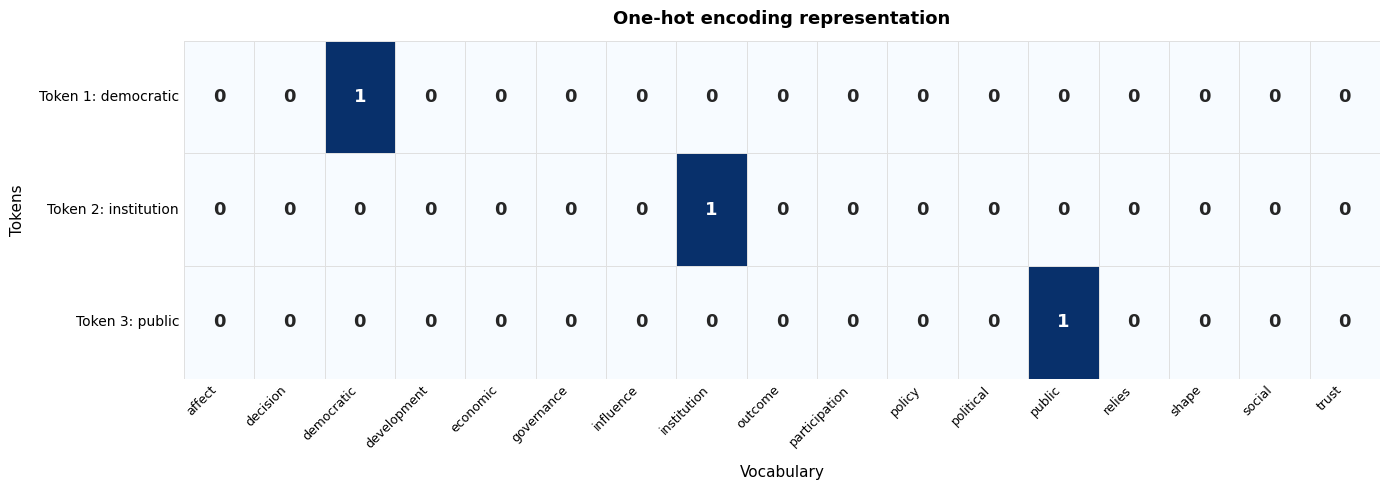

In [42]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    df_onehot,
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="#e0e0e0",
    annot=True,
    fmt="d",
    annot_kws={"size": 13, "fontweight": "bold"},
    ax=ax
)

ax.set_title(
    "One-hot encoding representation",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Vocabulary", fontsize=11, labelpad=10)
ax.set_ylabel("Tokens", fontsize=11, labelpad=10)

ax.set_yticklabels(
    [f"Token {i+1}: {tok}" for i, tok in enumerate(selected_tokens)],
    rotation=0, fontsize=10
)
ax.set_xticklabels(
    ax.get_xticklabels(), rotation=45, ha="right", fontsize=9
)

ax.tick_params(axis="both", length=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.savefig("onehot_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 9. Reflexión final

La vectorización de tokens es el medio para traducir el lenguaje en un sistema numérico que pueda ser reconocido e interpretado por modelos de aprendizaje automático, permitiendo así aplicar operaciones matemáticas y algoritmos sobre datos textuales que, de otro modo, no serían directamente procesables. A lo largo de este ejercicio, este proceso se ha abordado desde una perspectiva principalmente estructural, centrada en la forma en que los términos se representan: su distribución en los documentos (BoW), su ponderación dentro del corpus (TF-IDF) y la relación entre vectores mediante medidas como la similitud coseno.

Aunque estas aproximaciones presentan limitaciones, al enfocarse más en la forma que en el fondo del corpus, resulta incuestionable que constituyen etapas fundamentales en la construcción de modelos de procesamiento de lenguaje natural. Representaciones como BoW y TF-IDF permiten transformar el texto en estructuras numéricas manejables, preservando información clave sobre la presencia y relevancia de los términos. Sobre esta base, métricas como la similitud coseno hacen posible comparar documentos de manera eficiente, traduciendo la pregunta “¿se parecen estos dos textos?” en una operación algebraica, el cálculo del ángulo entre vectores en un espacio de alta dimensión. Esta abstracción es esencial, ya que habilita el uso de algoritmos de clasificación, agrupamiento y recuperación de información, los cuales requieren entradas numéricas bien definidas para operar.

Los esquemas de ponderación como TF-IDF introducen una mejora significativa frente a los conteos crudos, al diferenciar entre términos frecuentes en todo el corpus, que aportan poca capacidad discriminativa, y aquellos que son frecuentes dentro de un documento específico pero raros en los demás, los cuales permiten identificar su contenido temático. Como resultado, la similitud coseno calculada sobre vectores TF-IDF ofrece una representación más informativa del contenido de los textos que la obtenida a partir de BoW.

No obstante, este enfoque continúa limitado a la dimensión superficial del lenguaje, ya que no captura el significado de las palabras ni las relaciones semánticas entre ellas. En otras palabras, se modela cómo aparecen los términos, pero no lo que significan en contexto. Adicionalmente, estos métodos implican que el vocabulario crezca con el corpus, lo que da lugar a vectores cada vez más dispersos y de alta dimensión. Esta característica no solo incrementa el costo computacional, sino que también puede afectar la calidad de las comparaciones al introducir mayor ruido en el espacio vectorial.

---

## Apéndice: versiones de librerías

In [ ]:
import sklearn, nltk
import importlib.metadata as meta

libs = ['numpy', 'pandas', 'scikit-learn', 'nltk']
print('Versiones de librerías:')
for lib in libs:
    try:
        v = meta.version(lib)
    except Exception:
        v = 'no instalada'
    print(f'  {lib:<20} {v}')